In [1]:
import os
import xarray as xr
import numpy as np
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import contextlib
import warnings

from shapely.geometry import LineString, Point, Polygon
from tqdm import tqdm
from graph_creation import interpolate_variable

##### Paths

In [2]:
data_path = "raw_datasets_mesh/Simulations/output_2_map.nc"
xyz_file = "raw_datasets_mesh/DEM/DEM_2.xyz"
inflow_file = "raw_datasets_mesh/Hydrograph/Hydrograph_2.txt"
ds = xr.open_dataset(
    data_path
)
df = pd.read_csv(xyz_file, sep='\s+', header=None, names=['x', 'y', 'z'])
df_inflow = pd.read_csv(inflow_file, sep='\s+', header=None, names=['time', 'inflow'])

out_folder = "raw_datasets_mesh/Shapefiles/M02"
os.makedirs(out_folder, exist_ok=True)

Number of points: DEM=7935, Simulation=7935


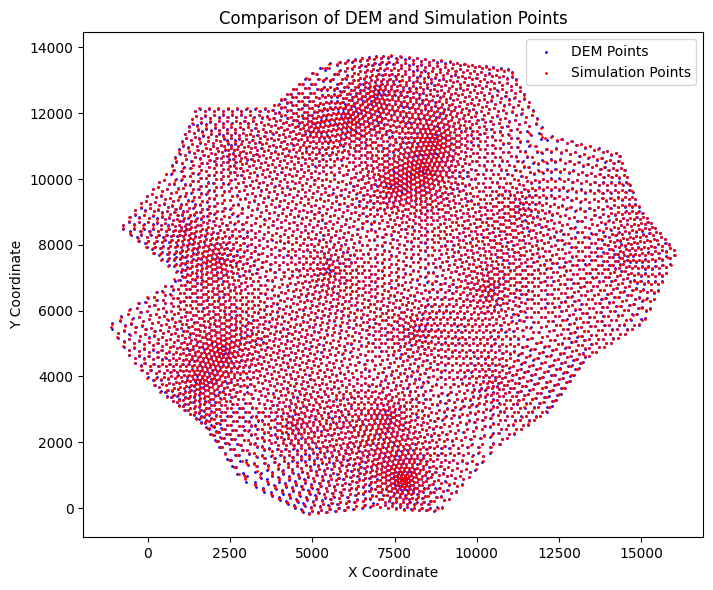

In [3]:
# Plot x and y coordinates for ds (.nc simulation) vs df (DEM)

sim_x = ds["mesh2d_face_x"].values
sim_y = ds["mesh2d_face_y"].values
gdf_sim = gpd.GeoDataFrame(geometry=[Point(x, y) for x, y in zip(sim_x, sim_y)])

dem_x = df['x'].values
dem_y = df['y'].values
gdf_dem = gpd.GeoDataFrame(geometry=[Point(x, y) for x, y in zip(dem_x, dem_y)])

print(f"Number of points: DEM={len(gdf_dem)}, Simulation={len(gdf_sim)}")

fig, ax = plt.subplots(figsize=(8, 8))
gdf_dem.plot(ax=ax, color='blue', markersize=1, label='DEM Points')
gdf_sim.plot(ax=ax, color='red', markersize=1, label='Simulation Points')
plt.legend()
plt.title('Comparison of DEM and Simulation Points')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.show()

### Get Geometry Details

#### Create Nodes Shapefile
##### Node_id starts with 1

#### Create Links Shapefile
##### Link_id starts with 1
##### Includes Ghost Links ("to_node" = -1)

#### Create Cell Polygon Shapefile
##### cell_id starts with 1

In [4]:
def create_mesh_gdfs(ds, df):
    # CRS (assign if known)
    EPSG = None  # e.g., "EPSG:3857" or "EPSG:4326"

    # ================== DATASET PROPERTIES ===================
    # Node properties
    centroid_x = ds["mesh2d_face_x"].values
    centroid_y = ds["mesh2d_face_y"].values

    # Edge coordinates (for boundary edges)
    edge_x = ds["mesh2d_edge_x"].values
    edge_y = ds["mesh2d_edge_y"].values

    # Edge-face connectivity (1-based)
    edge_faces = ds["mesh2d_edge_faces"].values
    assert np.all(~np.isnan(edge_faces)), "Edge-face connectivity contains NaN values."
    edge_faces = edge_faces.astype(int) - 1 # Convert to 0-based indexing

    # Edge type (1:normal edges, 2:BC_edge, 3:other boundary edges)
    edge_type = ds['mesh2d_edge_type'].values.astype(int)

    # Global node coordinates (mesh vertices)
    node_x = ds['mesh2d_node_x'].values
    node_y = ds['mesh2d_node_y'].values

    # Face connectivity (1-based indexing, with NaN for unused nodes)
    face_nodes = ds['mesh2d_face_nodes'].values

    # ================== CREATE NODES ===================
    centroid_xy = np.column_stack((centroid_x, centroid_y))
    dem_xy = df[['x', 'y']].values
    dem_elevation = df['z'].values
    elevation = interpolate_variable(centroid_xy, dem_xy, dem_elevation, method='nearest')

    node_type = np.ones_like(centroid_x)

    # ================== CREATE EDGES ===================
    # Edge properties
    link_geometries = []
    edge_ids = []
    from_faces = []
    to_faces = []
    length = []
    slope = []
    face_length = []

    # Boundary node properties
    b_centroid_x = []
    b_centroid_y = []
    b_node_type = []

    for edge_id, (f1, f2) in enumerate(edge_faces):
        is_not_boundary_edge = (f1 >= 0 and f2 >= 0)
        if is_not_boundary_edge:
            # Interior edge: centroid to centroid
            x1, y1 = centroid_x[f1], centroid_y[f1]
            x2, y2 = centroid_x[f2], centroid_y[f2]

            # Get valid nodes for this face, convert to 0-based
            # Filter face_nodes[f1, :] to remove NaNs
            face_nodes_f1 = face_nodes[f1, :]
            face_nodes_f1 = face_nodes_f1[~np.isnan(face_nodes_f1)].astype(int) - 1
            face_nodes_f2 = face_nodes[f2, :]
            face_nodes_f2 = face_nodes_f2[~np.isnan(face_nodes_f2)].astype(int) - 1
            shared_nodes = np.intersect1d(face_nodes_f1, face_nodes_f2)
            assert len(shared_nodes) == 2, "Expected exactly two shared nodes between adjacent faces."
            sn1, sn2 = shared_nodes
            curr_face_length = LineString([(node_x[sn1], node_y[sn1]), (node_x[sn2], node_y[sn2])]).length

            curr_geometry = LineString([(x1, y1), (x2, y2)])
            curr_from_face, curr_to_face = f1, f2
            curr_slope = (elevation[f2] - elevation[f1]) / curr_geometry.length
        else:
            edge_type_value = edge_type[edge_id]
            assert edge_type_value in [2, 3], f"Unexpected edge type {edge_type_value} for boundary edge."

            # Create boundary node at edge midpoint
            node_idx = len(centroid_x) + len(b_centroid_x) # New node index (0-based to match edge_faces)
            x1, y1 = edge_x[edge_id], edge_y[edge_id]
            b_centroid_x.append(x1)
            b_centroid_y.append(y1)
            b_node_type.append(edge_type_value)

            # Inflow boundary edge: use edge midpoint → face centroid
            x2 = centroid_x[f1] if f1 >= 0 else centroid_x[f2]
            y2 = centroid_y[f1] if f1 >= 0 else centroid_y[f2]

            curr_geometry = LineString([(x1, y1), (x2, y2)])
            curr_from_face, curr_to_face = node_idx, f1 if f1 >= 0 else f2
            curr_slope = 0.0  # Slope for boundary edges set to 0
            curr_face_length = 0.0 # Face length for boundary edges set to 0

        link_geometries.append(curr_geometry)
        edge_ids.append(edge_id + 1)  # 1-based
        from_faces.append(curr_from_face)
        to_faces.append(curr_to_face)
        length.append(curr_geometry.length)
        slope.append(curr_slope)
        face_length.append(curr_face_length)

    # ================== CREATE CELLS ===================

    face_geometries = []
    area_m2 = []
    n_faces, max_nodes = face_nodes.shape
    for i in range(n_faces):
        # Get valid nodes for this face, convert to 0-based
        nodes = face_nodes[i, :]
        nodes = nodes[~np.isnan(nodes)].astype(int) - 1  # convert 1-based → 0-based

        # Safety check
        if len(nodes) < 3:
            continue  # cannot create polygon

        # Polygon coordinates from global nodes
        coords = [(node_x[n], node_y[n]) for n in nodes]
        polygon = Polygon(coords)
        face_geometries.append(polygon)
        area_m2.append(polygon.area)
    
    # ================== ADD GHOST NODES ===================
    b_elevation = np.zeros(len(b_centroid_x))
    centroid_x = np.concatenate([centroid_x, np.array(b_centroid_x)])
    centroid_y = np.concatenate([centroid_y, np.array(b_centroid_y)])
    elevation = np.concatenate([elevation, b_elevation])
    node_type = np.concatenate([node_type, np.array(b_node_type)])

    for x, y in zip(b_centroid_x, b_centroid_y):
        polygon = Point(x, y).buffer(0.1)  # small buffer to create a polygon
        face_geometries.append(polygon)
        area_m2.append(0.0)
    
    # ================= CREATE GEODATAFRAMES ===================
    node_ids = range(1, len(centroid_x) + 1) # 1-based
    face_ids = range(1, len(face_geometries) + 1) # 1-based
    assert len(node_ids) == len(centroid_x), "Node ID and Face ID count mismatch."

    gdf_centroids = gpd.GeoDataFrame(
        {
            "node_id": node_ids,
            "X": centroid_x,
            "Y": centroid_y,
            "Elevation1": elevation,
            "node_type": node_type,
        },
        geometry=[Point(x, y) for x, y in zip(centroid_x, centroid_y)],
        crs=EPSG
    )

    gdf_links = gpd.GeoDataFrame(
        {
            "link_id": edge_ids,
            "from_node": from_faces,
            "to_node": to_faces,
            "edge_type": edge_type,
            "length": length,
            "slope": slope,
            "fc_length": face_length,
        },
        geometry=link_geometries,
        crs=EPSG
    )

    gdf_faces = gpd.GeoDataFrame(
        {
            "cell_id": face_ids,
            "area_m2": area_m2,
        },
        geometry=face_geometries,
        crs=EPSG
    )

    return gdf_centroids, gdf_links, gdf_faces

gdf_centroids, gdf_links, gdf_faces = create_mesh_gdfs(ds, df)

In [5]:
def save_shapefiles(gdf_centroids, gdf_links, gdf_faces, out_folder):
    # Paths
    nodes_out_file = os.path.join(out_folder, "Nodes.shp")
    edges_out_file = os.path.join(out_folder, "Links.shp")
    cells_out_file = os.path.join(out_folder, "Cells.shp")

    # Save shapefile
    gdf_centroids.to_file(nodes_out_file)
    gdf_links.to_file(edges_out_file)
    gdf_faces.to_file(cells_out_file)

    print(f"Saved cell centroids shapefile: {nodes_out_file}")
    print(f"Saved cell-centre links shapefile (including boundary edges): {edges_out_file}")
    print(f"Saved cells shapefile: {cells_out_file}")

save_shapefiles(gdf_centroids, gdf_links, gdf_faces, out_folder)
ds.close()

c:\Users\Carlo\Documents\School\Masters\NUS\Dissertation\mSWE-GNN\venv\lib\site-packages\pyogrio\geopandas.py:912: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(
c:\Users\Carlo\Documents\School\Masters\NUS\Dissertation\mSWE-GNN\venv\lib\site-packages\pyogrio\geopandas.py:912: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


Saved cell centroids shapefile: raw_datasets_mesh/Shapefiles/M02\Nodes.shp
Saved cell-centre links shapefile (including boundary edges): raw_datasets_mesh/Shapefiles/M02\Links.shp
Saved cells shapefile: raw_datasets_mesh/Shapefiles/M02\Cells.shp


c:\Users\Carlo\Documents\School\Masters\NUS\Dissertation\mSWE-GNN\venv\lib\site-packages\pyogrio\geopandas.py:912: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


# Creating .shp files for dataset

In [6]:
def create_shp_files_for_dataset(start_sim: int, n_sim: int, silent: bool = False):
    for i in tqdm(range(start_sim, start_sim+n_sim)):
        data_path = f"raw_datasets_mesh/Simulations/output_{i}_map.nc"
        xyz_file = f"raw_datasets_mesh/DEM/DEM_{i}.xyz"

        ds = xr.open_dataset(data_path)
        df = pd.read_csv(xyz_file, sep='\s+', header=None, names=['x', 'y', 'z'])
        
        out_folder = f"raw_datasets_mesh/Shapefiles/M{i}"
        os.makedirs(out_folder, exist_ok=True)

        gdf_centroids, gdf_links, gdf_faces = create_mesh_gdfs(ds, df)
        if silent:
            with contextlib.redirect_stdout(None):
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    save_shapefiles(gdf_centroids, gdf_links, gdf_faces, out_folder)
        else:
            save_shapefiles(gdf_centroids, gdf_links, gdf_faces, out_folder)

create_shp_files_for_dataset(start_sim=1, n_sim=100, silent=True)

100%|██████████| 100/100 [03:50<00:00,  2.30s/it]


### Get Simulation Results

#### Flows along links (m^3/s)

In [7]:
# Extract discharge DataArray
q1 = ds["mesh2d_q1"]  # (time, mesh2d_nEdges)

# Convert to DataFrame
df_flow = pd.DataFrame(
    data=q1.values,
    index=q1["time"].values,
    columns=np.arange(1, q1.shape[1] + 1)  # link IDs start at 1
)

# Name index and columns (good practice)
df_flow.index.name = "time"
df_flow.columns.name = "link_id"

ds.close()

df_flow

link_id,1,2,3,4,5,6,7,8,9,10,...,11990,11991,11992,11993,11994,11995,11996,11997,11998,11999
time,,,,,,,,,,,,,,,,,,,,,
2023-09-05 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-09-05 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-09-05 02:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-09-05 03:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-09-05 04:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-09-08 20:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-09-08 21:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-09-08 22:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### Water Depth (m)

In [8]:
wd = ds["mesh2d_waterdepth"]  # (time, mesh2d_nFaces)

df_depth = pd.DataFrame(
    data=wd.values,
    index=wd["time"].values,
    columns=np.arange(1, wd.shape[1] + 1)  # cell IDs start at 1
)

df_depth.index.name = "time"
df_depth.columns.name = "cell_id"

ds.close()

df_depth

cell_id,1,2,3,4,5,6,7,8,9,10,...,7926,7927,7928,7929,7930,7931,7932,7933,7934,7935
time,,,,,,,,,,,,,,,,,,,,,
2023-09-05 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2023-09-05 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.089030,0.078942,0.059765,0.081051,0.128756,0.101141,0.065529,0.118698,0.105232,0.110072
2023-09-05 02:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.115032,0.102165,0.077430,0.098265,0.148094,0.123841,0.082029,0.137637,0.124769,0.128577
2023-09-05 03:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.129353,0.114293,0.089263,0.111698,0.164485,0.137781,0.094473,0.153076,0.138729,0.142821
2023-09-05 04:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.142647,0.125613,0.100529,0.124372,0.179706,0.150714,0.106137,0.167453,0.151769,0.156139
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-09-08 20:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.014681,0.013807,0.007922,0.010852,0.018106,0.017077,0.008202,0.017029,0.016188,0.016463
2023-09-08 21:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.013975,0.013151,0.007532,0.010324,0.017207,0.016265,0.007797,0.016191,0.015402,0.015661
2023-09-08 22:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.013305,0.012529,0.007162,0.009823,0.016356,0.015494,0.007414,0.015397,0.014657,0.014900


#### Water Volume (Water depth * Area): m^3

In [9]:
cells = gpd.read_file(os.path.join(out_folder, "Cells.shp"))

# Create area Series indexed by face id (1-based)
area = cells.set_index("cell_id")["area_m2"]
volume_df = df_depth.mul(area, axis=1)
volume_df

cell_id,1,2,3,4,5,6,7,8,9,10,...,8118,8119,8120,8121,8122,8123,8124,8125,8126,8127
time,,,,,,,,,,,,,,,,,,,,,
2023-09-05 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-09-05 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-09-05 02:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-09-05 03:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-09-05 04:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-09-08 20:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-09-08 21:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-09-08 22:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Identify Boundary Link

In [10]:
# Sum flow over all times for each link (column-wise)
total_flow_per_link = df_flow.sum(axis=0)

# Link ID with maximum total flow
max_link_id = total_flow_per_link.idxmax()
max_total_flow = total_flow_per_link.loc[max_link_id]

print(f"Link ID with max total flow: {max_link_id}")
print(f"Total flow over time: {max_total_flow:.3f} m3")

Link ID with max total flow: 11808
Total flow over time: 9200.919 m3


#### Boundary timeseries

In [11]:
df_inflow['time_hours'] = df_inflow['time'] / 3600
print(df_inflow)

      time   inflow  time_hours
0        0  35.9398         0.0
1     3600  47.8976         1.0
2     7200  61.9788         2.0
3    10800  78.0491         3.0
4    14400  95.8549         4.0
..     ...      ...         ...
92  331200   1.2368        92.0
93  334800   1.1295        93.0
94  338400   1.0314        94.0
95  342000   0.9417        95.0
96  345600   0.8598        96.0

[97 rows x 3 columns]


In [12]:
def check_inflow_consistency(start_sim: int = 1, n_sim: int = 99):
    for i in range(start_sim, start_sim + n_sim):
        nc_file = f"raw_datasets_mesh/Simulations/output_{i}_map.nc"
        inflow_file = f"raw_datasets_mesh/Hydrograph/Hydrograph_{i}.txt"
        ds = xr.open_dataset(nc_file)
        df_inflow = pd.read_csv(inflow_file, sep='\s+', header=None, names=['time', 'inflow'])

        q1 = ds["mesh2d_q1"]  # (time, mesh2d_nEdges)
        test_flow = q1.values
        edge_type = ds['mesh2d_edge_type'].values.astype(int)
        bc_edge_idx = np.where(edge_type == 2)[0]
        sim_inflow = test_flow[:, bc_edge_idx].squeeze()

        txt_inflow = df_inflow['inflow'].values

        mismatched = np.where(~np.isclose(sim_inflow, txt_inflow, atol=1e-2))[0]
        print(f"Simulation {i} has {len(mismatched)} mismatched inflow values at indices: {mismatched}")

check_inflow_consistency(n_sim=1)

Simulation 1 has 1 mismatched inflow values at indices: [0]


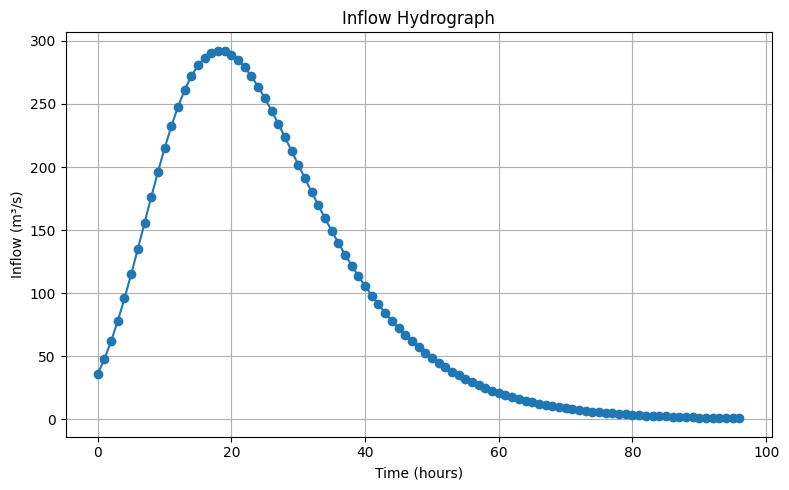

In [13]:
# Plot
plt.figure(figsize=(8,5))
plt.plot(df_inflow['time_hours'], df_inflow['inflow'], marker='o', linestyle='-')
plt.xlabel("Time (hours)")
plt.ylabel("Inflow (m³/s)")
plt.title("Inflow Hydrograph")
plt.grid(True)
plt.tight_layout()
plt.show()

#### Other Details

##### Uniform Manning's Rougness value of 0.023
##### First train the model on synthetic data (100 events) and then test on real case (zero-shot and after transfer learning)
##### On synthetic data: 100 events, train: 60, validation: 20, test: 20
##### No outflows, only inflows
##### No rainfall inputs

In [14]:
BC_edge_idx = None
for i in range(1, 101):
    path = f'raw_datasets_mesh/Simulations/output_{i}_map.nc'
    ds = xr.open_dataset(path)
    edge_type = ds['mesh2d_edge_type'].data # 1:normal edges, 2:BC_edge, 3:other boundary edges
    inflow_edge_idx = np.where(edge_type == 2)[0]
    if not BC_edge_idx:
        BC_edge_idx = inflow_edge_idx
    if BC_edge_idx != inflow_edge_idx:
        print(f"Inflow edges are not the same for sim {i}: {BC_edge_idx} v.s. {inflow_edge_idx}")
        break

# Boundary condition per graph is different along with graph structure

Inflow edges are not the same for sim 2: [14001] v.s. [11807]


### Physics-informed

In [15]:
node_types = gdf_centroids['node_type'].values
Ghost_cells_idx = np.where(node_types != 1)[0]

edge_index = gdf_links[['from_node', 'to_node']].values  # 0-based node indices
from_links = []
to_links = []

for node_idx in range(len(gdf_centroids)):
    from_link_positions = np.where(edge_index[:, 0] == node_idx)[0]  # Links starting from this node
    to_link_positions = np.where(edge_index[:, 1] == node_idx)[0]    # Links ending at this node
    from_links.append(from_link_positions.tolist())
    to_links.append(to_link_positions.tolist())

time_list = df_flow.index.tolist()

vol_df_clean = volume_df.drop(columns=Ghost_cells_idx + 1)  # +1 for 1-based indexing

In [16]:
def local_cell_vol_error_for_timestep(cell_index,time_index,delta_t):
    if cell_index not in Ghost_cells_idx:
        from_node_links = from_links[cell_index] # links starting from the cell index (positive direction outward)
        to_node_links = to_links[cell_index] # links ending at the cell index (positive direction inward)         
        Vt = volume_df.iloc[time_index, cell_index]
        vt_plus_1 = volume_df.iloc[time_index+1, cell_index]
        print(f'current volume (m3): {Vt}')
        print(f'next volume (m3): {vt_plus_1}')
        delta_v = vt_plus_1 - Vt
        print(f'cell volume change (m3): {delta_v}')

        # No rainfall volume contribution
        # rf_volume = rain_increment[str(cell_index)][time_index]
        # print(f'rainfall volume (m3): {rf_volume}')
    
        vol_in = 0
        vol_out = 0
        if len(from_node_links) > 0:
            for link in from_node_links:
                print(f'Link {link} starts from Node {cell_index}')
                vflux = (df_flow.iloc[time_index, link])*delta_t
                #vflux = ((flow_df[str(link)][time_index])+(flow_df[str(link)][time_index+1]))*delta_t/2 # use this if delta t is different from 30 s
                if vflux >= 0:
                    vol_out = vol_out+abs(vflux)
                else:
                    vol_in = vol_in+abs(vflux)
        if len(to_node_links) > 0:
            for link in to_node_links:
                print(f'Link {link} ends at Node {cell_index}')
                vflux = (df_flow.iloc[time_index, link])*delta_t
                #vflux = ((flow_df[str(link)][time_index])+(flow_df[str(link)][time_index+1]))*delta_t/2 # use this if delta t is different from 30 s
                if vflux >= 0:
                    vol_in = vol_in+abs(vflux)
                else:
                    vol_out = vol_out+abs(vflux)
        print(f'volume in (m3):{vol_in}')
        print(f'volume out (m3):{vol_out}')
    
        vol_error = delta_v - vol_in + vol_out # - rf_volume
        print(f'Volume error of cell {cell_index} between {time_list[time_index]} and {time_list[time_index+1]}: {vol_error} m3')
        return vol_error
    else:
        print('Ghost cell: exclude from volume error calculation')
        return 0

In [17]:
test = np.unique(np.where(volume_df > 0)[1])
print(test.tolist())

[1272, 1273, 1274, 1341, 1342, 1343, 1344, 1410, 1411, 1412, 1414, 1477, 1481, 1482, 1483, 1484, 1485, 1548, 1551, 1552, 1553, 1554, 1555, 1556, 1619, 1620, 1621, 1622, 1623, 1624, 1625, 1626, 1627, 1669, 1676, 1690, 1691, 1692, 1693, 1694, 1695, 1696, 1697, 1698, 1733, 1741, 1742, 1743, 1744, 1745, 1746, 1747, 1748, 1760, 1761, 1762, 1763, 1764, 1765, 1766, 1767, 1768, 1769, 1785, 1786, 1804, 1812, 1813, 1814, 1815, 1816, 1817, 1818, 1819, 1831, 1832, 1833, 1834, 1835, 1836, 1837, 1838, 1839, 1840, 1855, 1856, 1857, 1858, 1859, 1876, 1884, 1885, 1886, 1887, 1888, 1889, 1890, 1891, 1902, 1903, 1904, 1905, 1906, 1907, 1908, 1909, 1910, 1911, 1926, 1927, 1928, 1929, 1930, 1947, 1955, 1956, 1957, 1958, 1959, 1960, 1961, 1962, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1997, 1998, 1999, 2000, 2001, 2002, 2019, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034, 2044, 2045, 2046, 2047, 2048, 2049, 2050, 2051, 2052, 2053, 2069, 2070, 2071, 2072, 2073, 2090, 2098, 2099, 2100, 210

In [18]:
cell_index = 1858 # node number where local mass balance to calculate
time_index = 90 # time of the event mass balance is calculated
delta_t = 3600 # time interval in seconds

local_cell_vol_error_for_timestep(cell_index,time_index,delta_t)

current volume (m3): 4696.61146025893
next volume (m3): 4767.045978230668
cell volume change (m3): 70.43451797173839
Link 2667 ends at Node 1858
Link 2669 ends at Node 1858
Link 2833 ends at Node 1858
volume in (m3):189.4439856147741
volume out (m3):117.70263299543817
Volume error of cell 1858 between 2023-09-08 18:00:00 and 2023-09-08 19:00:00: -1.3068346475975545 m3


-1.3068346475975545

In [19]:
def total_local_vol_error_for_timestep(time_index, delta_t):
    local_vol_error_for_ts = []
    for cell_index in range(len(gdf_centroids)):
        with contextlib.redirect_stdout(open(os.devnull, 'w')):
            vol_error = local_cell_vol_error_for_timestep(cell_index, time_index, delta_t)
            local_vol_error_for_ts.append(vol_error)
    total_local_vol_error_for_ts = np.abs(local_vol_error_for_ts).sum()
    return total_local_vol_error_for_ts

total_local_vol_error_for_ts = total_local_vol_error_for_timestep(time_index, delta_t)
print(f'Total local volume error for all cells: {total_local_vol_error_for_ts} m3')

Total local volume error for all cells: 2182.9602097030597 m3


In [20]:
all_local_vol_errors = []
for i in range(len(time_list) - 2):
    with contextlib.redirect_stdout(open(os.devnull, 'w')):
        loss = total_local_vol_error_for_timestep(i, delta_t)
        all_local_vol_errors.append(loss)

    if i % 20 == 0:
        print(f'Processed {i} time steps')

Processed 0 time steps
Processed 20 time steps
Processed 40 time steps
Processed 60 time steps
Processed 80 time steps


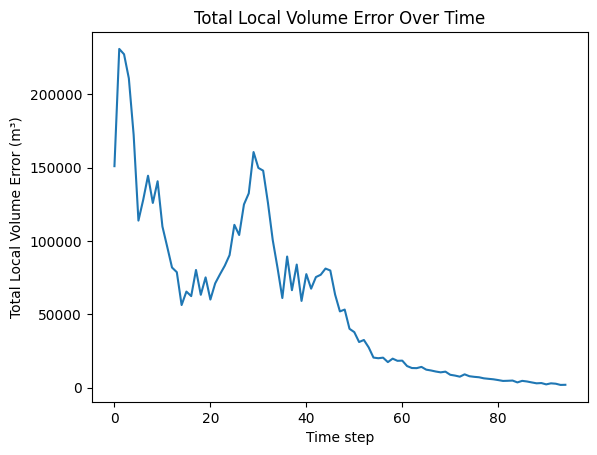

In [21]:
local_vol_errors_to_plot = all_local_vol_errors
plt.plot(local_vol_errors_to_plot)
plt.xlabel('Time step')
plt.ylabel('Total Local Volume Error (m³)')
plt.title('Total Local Volume Error Over Time')
plt.show()

In [22]:
def global_domain_vol_error_for_time_interval(start_time,end_time,delta_t):
    volume_start = np.sum(vol_df_clean.iloc[start_time, 1:])
    volume_end = np.sum(vol_df_clean.iloc[end_time, 1:])
    print(f'Strat volume (m3): {volume_start}')
    print(f'End volume (m3): {volume_end}')
    delta_v = volume_end - volume_start
    print(f'Total cell volume change (m3): {delta_v}')

    # No rainfall volume contribution
    # rf_volume = np.sum((rain_df.iloc[end_time, 1:])*area/1000) - np.sum((rain_df.iloc[start_time, 1:])*area/1000)
    # rf_volume = np.sum(rain_increment.iloc[start_time, 1:])
    # print(f'Total rain volume (m3): {rf_volume}')

    inflow_volume = np.sum(df_inflow['inflow'][start_time:end_time])*delta_t
    print(f'Total inflow volume (m3): {inflow_volume}')

    # No outflow boundary volume contribution
    # outflow_volume = np.sum(outflow_ds[start_time:end_time])*delta_t
    # print(f'Total outflow volume (m3): {outflow_volume}')

    global_volume_error = delta_v - inflow_volume # + outflow_volume - rf_volume
    return global_volume_error

In [23]:
start_time = 90 # can have values from 0 to len(time_list)-2
end_time = 91 # # can have values from 1 to len(time_list)-1
delta_t = 3600 # time interval in seconds
print(f'start time: {time_list[start_time]}')
print(f'end time: {time_list[end_time]}')

global_domain_vol_error_for_time_interval(start_time,end_time,delta_t)

start time: 2023-09-08 18:00:00
end time: 2023-09-08 19:00:00
Strat volume (m3): 33161383.761145506
End volume (m3): 33166487.536645494
Total cell volume change (m3): 5103.775499988347
Total inflow volume (m3): 5336.639999999999


-232.86450001165213

In [24]:
all_global_vol_errors = []
for i in range(len(time_list) - 2):
    with contextlib.redirect_stdout(open(os.devnull, 'w')):
        loss = global_domain_vol_error_for_time_interval(i, i + 1, delta_t)
        loss = np.abs(loss)
        all_global_vol_errors.append(loss)

    if i % 20 == 0:
        print(f'Processed {i} time steps')

Processed 0 time steps
Processed 20 time steps
Processed 40 time steps
Processed 60 time steps
Processed 80 time steps


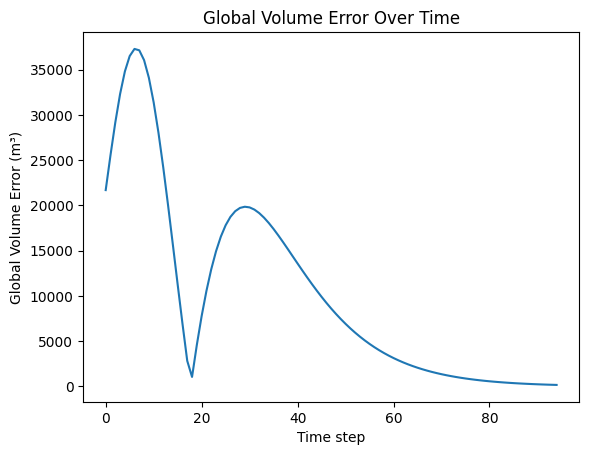

In [25]:
global_vol_errors_to_plot = all_global_vol_errors
plt.plot(global_vol_errors_to_plot)
plt.xlabel('Time step')
plt.ylabel('Global Volume Error (m³)')
plt.title('Global Volume Error Over Time')
plt.show()